# Detecting Exo-Planets Using Transit Photometry

**Author**: Amy Hickson

**Date:** 02/26

**Data Source**: NASA TESS Mission via Lighkurve


## Abstract

Analysising publically available photometric time-series data from the NASA TESS mission in order to detect periodic dips in brightness which indicate the presence of an orbiting exoplanet. The data is cleaned and detrended before a period search algorithm is applied to determine the exoplanet orbital period that best matches the data. The light curve is then phase-folded and the change in brightness is determined, which is then used to estimate the radius of the orbiting exoplanet. 
 
## 1. Introduction

The transit method involves analysising star light in order to detect periodic dips in brightness which could be caused by orbiting exoplanets. The NASA TESS mission (used here as a source of data) monitors the brightness of stars over a long period of time, providing vast amounts of data that can be searched for transiting exoplanets (other missions such as the Kepler mission collect similar data). In this project I will analyse photometric data from the TESS mission in order to determine if a given star has an orbiting exoplanet, I will then go on to estimate the radius of this planet.

In [3]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from astropy import units as u
from astropy.timeseries import BoxLeastSquares

import lightkurve as lk

## 2. Data Acquisition

I will use the 'lighkurve' Python packackage to access photometric data from the TESS mission. To start with I will choose a star which is known to have an orbiting exoplanet in order to ensure the method of analysis works correctly, the star I have chosen is HD 209458.

In [4]:
#search for and download light curve (HD 209458 is a star with an exoplanet in the contellation of pegasus)
search_result = lk.search_lightcurve("HD 209458", mission="TESS")
lc = search_result.download()

## 3. Initial Data Inspection

I will start by doing an initial plot of the light curve data to familiarise myself with its structure, noise level etc.

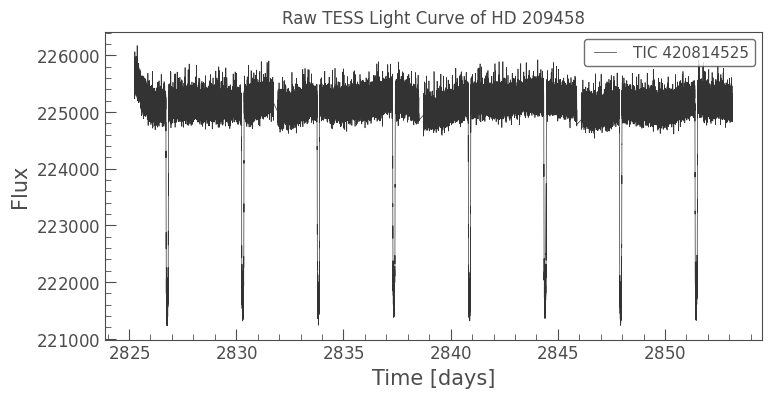

In [5]:
lc.plot()
plt.title("Raw TESS Light Curve of HD 209458")
plt.xlabel("Time [days]")
plt.ylabel("Flux")
plt.show()

## 4. Data Cleaning and Preprocessing

It's common for raw light curve data to contain missing data points, errors from measuring equipment and variations in brighness from long term behaviour of the star itself (rather than an orbiting exoplanet). It is important to remove these features in order to search the data for possible exoplanets.

In [6]:
# removing values that are not numbers and normalising
lc_clean = lc.remove_nans()
lc_clean = lc_clean.normalize()

lc_flat = lc_clean.flatten(window_length=401)

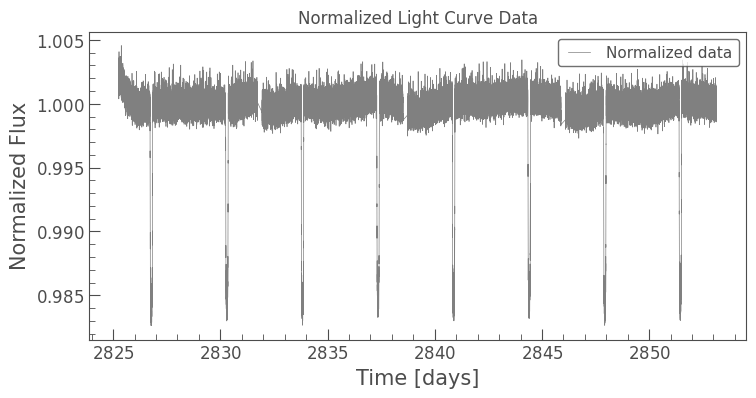

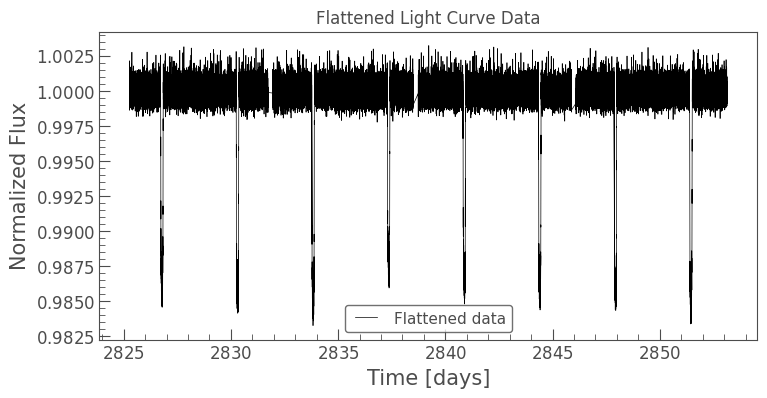

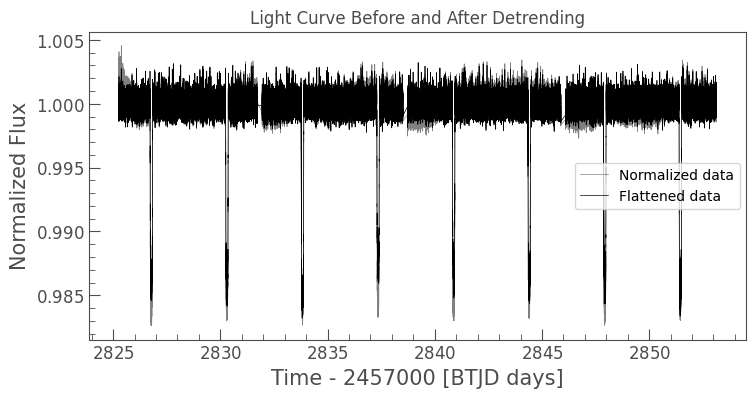

In [ ]:
#plot two graphs to compare data before and after detrending (removing impacts of long term behaviour of the star)
lc_clean.plot(label="Normalized data", color="grey")
plt.title("Normalized Light Curve Data")
plt.xlabel("Time [days]")
lc_flat.plot(label="Flattened data", color="black")
plt.title("Flattened Light Curve Data")
plt.xlabel("Time [days]")

# plot a graph of detrended data and original data to make comparison clearer
ax = lc_clean.plot(label="Normalized data", color="grey")
lc_flat.plot(ax=ax, label="Flattened data", color="black")
plt.legend()
plt.title("Light Curve Before and After Detrending")
plt.show()

## 5. Transit Search

In order to find potential dips in brightness due to an orbiting exoplanet I will use the Box Least Squares (BSL) algorithm. The Box Least Squares algorithm is used to detect box shaped dips in in a stars brightness which could be indicative of an orbiting exoplanet.

In [8]:
# creating an array of time values
time = lc_flat.time.value
# creating an array of flux (brightness) values
flux = lc_flat.flux.value

# creating a list of periods to try and match to the data 
periods = np.linspace(0.5, 10, 5000) # -> 5000 evenly spaces periods between 0.5 and 10 days
bls = BoxLeastSquares(time, flux)
# finding the period from the list which is the closest match to the data by assuming the transit lasts around 0.1 days
bls_power = bls.power(periods, 0.1)

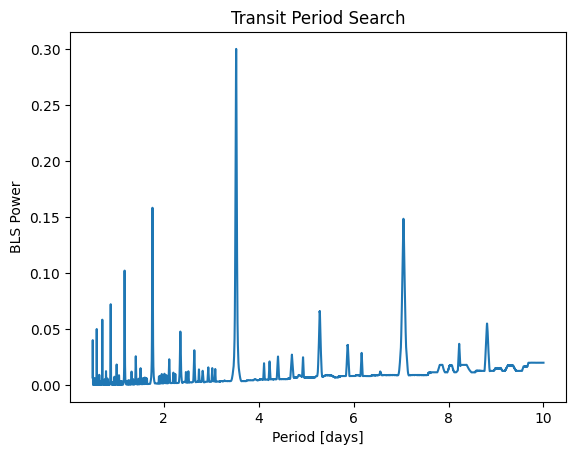

In [9]:
# plotting how closely each period from the list of test periods matches the data
plt.plot(periods, bls_power.power)
plt.xlabel("Period [days]")
plt.ylabel("BLS Power")
plt.title("Transit Period Search")
plt.show()

In [ ]:
# finding the period with the best match (highest power) to the data 
best_period = bls_power.period[np.argmax(bls_power.power)]
best_period

3.525405081016203

This suggests there is an exoplanet orbiting HD 209458 with an orbital period of approximately 3.52 days, this aligns with the current knowledge of HD 209458 (it is known to have an exoplanet HD 209458 b with an oribital period of 3.52 days [1]).

## 6. Phase-Folded Light Curve

Phase-folding is the process of plotting the brightness against its stage in the orbital period rather than just the raw time value. This means the data for multiple orbits can be stacked on top of eachother, reducing the amount of noise compared to the amount of useful data.

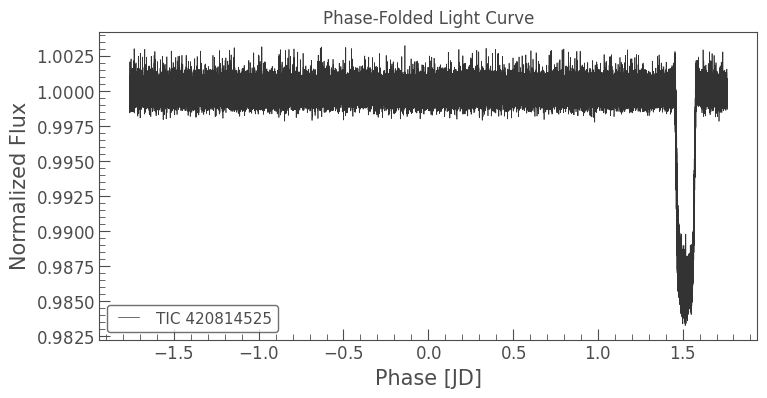

In [11]:
lc_folded = lc_flat.fold(period=best_period)
lc_folded.plot()
plt.title("Phase-Folded Light Curve")
plt.show()

This graph shows how the brightness of HD 209458 changes over the orbital period of its exoplanet, the dramatic dip in brightness occurs as the exoplanet passes in front of the star.

## 7. Measuring Planet properties

The transit depth of an exoplanet refers to the fraction of light from its star that it blocks.

Transit Depth =  $ I \approx  \frac{\Delta F}{F} = (\frac{R_p}{R_s})^2 $

Where F represents the brightness/flux of the star, $R_p$ represents the radius of the planet and $R_s$ represents the radius of the star.

As we can calculate the change in brightness/flux of the star using our light curve we can therefore calucate the ratio of the radius of the planet to the radius of the star.

In [14]:
# as the flux data is normalised the normal brightness of the star is approx 1
transit_depth = 1- np.min(lc_folded.flux.value)
radius_ratio = np.sqrt(transit_depth)

print("Transit Depth: ", transit_depth)
print("Radius Ratio: ", radius_ratio)

Transit Depth:  0.016750559585409275
Radius Ratio:  0.12942395290443448


An accepted value of the radius of HD 209458 [2] can then be used to calculate the radius of the orbiting exoplanet. 

$ R_s \approx 1.19 \times 6.96 * 10^8 = 8.28 \times 10^8 m$

$ R_p = R_s \sqrt I $

$ R_p \approx 8.28 \times 10^8 \times 0.129 = 1.07 \times 10^8m $


## 8. Repeating for a Second Candidate

Next I will carry out the same analysis on another star. I have chosen a random star from stellarcatalogue.com, 'HD 209290'.

## 9. Initial Data Cleaning and Analysis of Second Candidate

In [ ]:
# accessing most recent light curve for HD 209290
search_result = lk.search_lightcurve("HD 209290", mission="TESS")
lc2 = search_result.download()

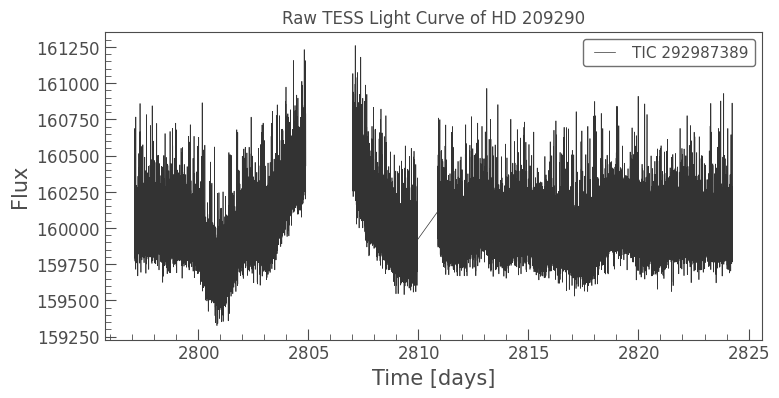

In [ ]:
# plotting a graph of raw data
lc2.plot()
plt.title("Raw TESS Light Curve of HD 209290")
plt.xlabel("Time [days]")
plt.ylabel("Flux")
plt.show()

In [26]:
# removing values that are not numbers and normalising
lc2_clean = lc2.remove_nans()
lc2_clean = lc2_clean.normalize()

lc2_flat = lc2_clean.flatten(window_length=401)

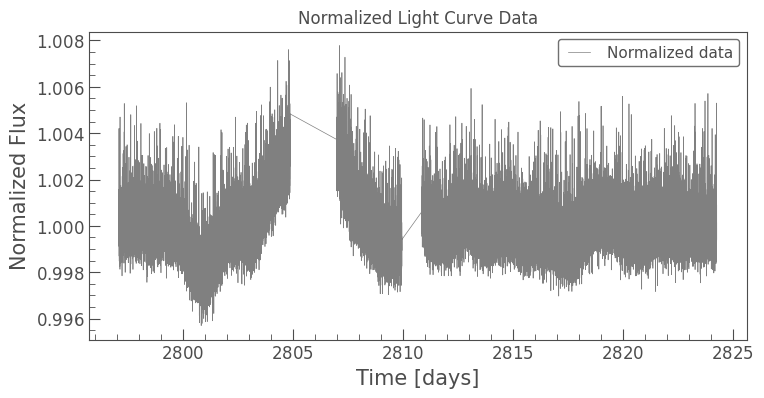

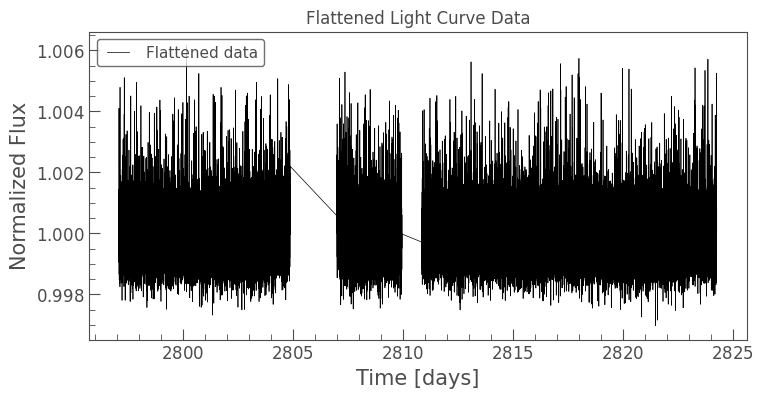

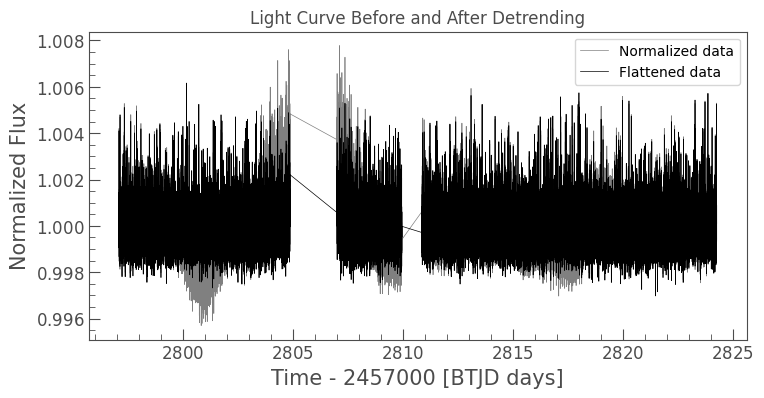

In [ ]:
#plot two graphs to compare data before and after detrending (removing impacts of long term behaviour of the star)
lc2_clean.plot(label="Normalized data", color="grey")
plt.title("Normalized Light Curve Data")
plt.xlabel("Time [days]")
lc2_flat.plot(label="Flattened data", color="black")
plt.title("Flattened Light Curve Data")
plt.xlabel("Time [days]")

# plot graph of detrended and original data to make comparison more obvious
ax = lc2_clean.plot(label="Normalized data", color="grey")
lc2_flat.plot(ax=ax, label="Flattened data", color="black")
plt.legend()
plt.title("Light Curve Before and After Detrending")
plt.show()

## 10. Transit Search of Second Candidate

Next, I will once again use the box least squares algorithm to search for potential orbiting exoplanets.

In [28]:
# creating an array of time values
time = lc2_flat.time.value
# creating an array of flux (brightness) values
flux = lc2_flat.flux.value

# creating a list of periods to try and match to the data 
periods = np.linspace(0.5, 10, 5000) # -> 5000 evenly spaces periods between 0.5 and 10 days
bls = BoxLeastSquares(time, flux)
# finding the period from the list which is the closest match to the data by assuming the transit lasts around 0.1 days
bls_power = bls.power(periods, 0.1)

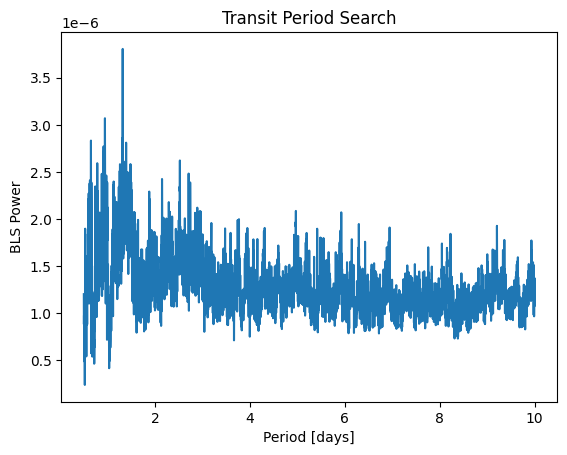

In [29]:
# plotting how closely each period from the list of test periods matches the data
plt.plot(periods, bls_power.power)
plt.xlabel("Period [days]")
plt.ylabel("BLS Power")
plt.title("Transit Period Search")
plt.show()

This graph shows the BLS Power values are dramatically smaller for HD 209290 than they are for HD 209458 (the initial star I analysised which has a known exoplanet), this strongly suggests that there is no exoplanet orbital period that matches the variation in brightness of HD 209290, and therefore no exoplanets orbiting the star. The BLS power values for HD 209290 also do not show the same sharp correlation that the BLS power values for HD 209458 show. The distribution of BLS power for HD 209290 is much more diffuse, providing further evidence for a lack of orbiting exoplanet.

This conclusion aligns with the current knowledge that HD 209290 has no known orbiting exoplanets [3].

## 11. Limitations and Sources of Uncertainty

As the transit depth is calculated using 1 - min(F) (where F is the flux of the star) a data point with an unusually low amount of noise could make the minimum flux value artifically lower. This would cause the estimated radius of the planet to be larger than the true value. Similarly, when the data is flattended the change in flux caused by the exoplanet transit may have been distorted which would produce errors in later calculations. Other factors such as noise and gaps (as seen for the light curve of HD 209290) in the data limit the accuracy of caluclations

## 12. Conclusion

This project has shown how publically available photometric data from the TESS mission can be analysised using Python in order to detect potential exoplanets. The method of data analysis has been used to successfully detect a known exoplanet orbiting a star and provide evidence for lack of exoplanet orbiting another star. The values derived from the data analysis were also successfully used to estimate the radius of the detected exoplanet. 

### References

[1] Stellar Catalogue, *Exoplanet HD 209458 b* [online] Last Accessed 6th February 2026: https://www.stellarcatalog.com/exoplanet.php?planetID=100230

[2] Stellar Catalogue, *Star HD 209458* [online] Last Accessed 6th February 2026: https://www.stellarcatalog.com/stars/hd-209458

[3] Stellar Catalogue, *Star HD 209290* [online] Last Accessed 6th February 2026: https://www.stellarcatalog.com/stars/hd-209290
